going to get looking at some data

In [1]:
import pandas as pd
import numpy as np

big_data_filepath = "C:\\Users\\samib\\OneDrive - Imperial College London\\Imperial\\Education\\Year 4\\Masters Project\\Code\\MastersProject\\Data\\2015-2025jSPXoptions.csv"

big_data = pd.read_csv(big_data_filepath)



In [2]:
# Inspect data structure
print("Dataset shape:", big_data.shape)
print("\nColumn names and types:")
print(big_data.info())
print("\nFirst few rows:")
print(big_data.head(5))
print("\nBasic statistics:")
print(big_data.describe())
print("\nData types:")
print(big_data.dtypes)
print("\nMissing values:")
print(big_data.isnull().sum())

Dataset shape: (42225530, 23)

Column names and types:
<class 'pandas.DataFrame'>
RangeIndex: 42225530 entries, 0 to 42225529
Data columns (total 23 columns):
 #   Column            Dtype  
---  ------            -----  
 0   secid             int64  
 1   date              str    
 2   symbol            str    
 3   exdate            str    
 4   cp_flag           str    
 5   strike_price      int64  
 6   best_bid          float64
 7   best_offer        float64
 8   volume            int64  
 9   open_interest     int64  
 10  impl_volatility   float64
 11  delta             float64
 12  gamma             float64
 13  vega              float64
 14  theta             float64
 15  optionid          int64  
 16  forward_price     float64
 17  expiry_indicator  str    
 18  index_flag        int64  
 19  issue_type        str    
 20  industry_group    float64
 21  issuer            str    
 22  exercise_style    str    
dtypes: float64(9), int64(6), str(8)
memory usage: 7.2 GB
None

Fi

In [3]:
columns_to_keep = ["secid", "date", "exdate", "cp_flag", "strike_price", "best_bid", "best_offer",
                    "optionid", "exercise_style", "impl_volatility", "delta", "vega", "gamma"]

filtered_data = big_data[columns_to_keep]
# Rename strike_price to K and divide by 1000
filtered_data = filtered_data.rename(columns={'strike_price': 'K'})
filtered_data['K'] = filtered_data['K'] / 1000

print(filtered_data.head(5))

#about equal number of calls and puts
#only european options

    secid        date      exdate cp_flag       K  best_bid  best_offer  \
0  108105  02/01/2015  17/01/2015       C   100.0    1956.4      1959.6   
1  108105  02/01/2015  17/01/2015       C  1000.0    1056.7      1059.9   
2  108105  02/01/2015  17/01/2015       C  1025.0    1031.7      1034.9   
3  108105  02/01/2015  17/01/2015       C  1050.0    1006.7      1009.8   
4  108105  02/01/2015  17/01/2015       C  1075.0     981.7       984.8   

    optionid exercise_style  impl_volatility     delta      vega     gamma  
0  101234071              E              NaN       NaN       NaN       NaN  
1  101234072              E         1.222229  0.999103  1.179546  0.000006  
2  101234073              E         1.181493  0.999083  1.204660  0.000006  
3  101234074              E         1.092237  0.999391  0.808892  0.000005  
4  101234075              E         1.054338  0.999382  0.820990  0.000005  


In [4]:
# Convert date column to datetime format (dd/mm/yyyy)
filtered_data['date'] = pd.to_datetime(filtered_data['date'], format='%d/%m/%Y')
filtered_data['exdate'] = pd.to_datetime(filtered_data['exdate'], format='%d/%m/%Y')

# Filter data to only include dates between 02/16/2015 and 01/07/2021
cutoff_date_start = pd.to_datetime('2017-10-16')
cutoff_date_end = pd.to_datetime('2021-07-01')
filtered_data = filtered_data[(filtered_data['date'] >= cutoff_date_start) & (filtered_data['date'] < cutoff_date_end)]

print(f"Dataset shape after date filter: {filtered_data.shape}")
print(f"\nDate range: {filtered_data['date'].min()} to {filtered_data['date'].max()}")
print(f"\nFirst few rows:")
print(filtered_data.head())

Dataset shape after date filter: (14062856, 13)

Date range: 2017-10-16 00:00:00 to 2021-06-30 00:00:00

First few rows:
          secid       date     exdate cp_flag       K  best_bid  best_offer  \
5693176  108105 2017-10-16 2017-10-20       C  1000.0    1554.8      1560.4   
5693177  108105 2017-10-16 2017-10-20       C  1100.0    1454.9      1460.5   
5693178  108105 2017-10-16 2017-10-20       C  1200.0    1354.9      1360.5   
5693179  108105 2017-10-16 2017-10-20       C  1225.0    1329.9      1335.5   
5693180  108105 2017-10-16 2017-10-20       C  1250.0    1304.9      1310.5   

          optionid exercise_style  impl_volatility  delta  vega  gamma  
5693176  116329689              E              NaN    NaN   NaN    NaN  
5693177  116329690              E              NaN    NaN   NaN    NaN  
5693178  116329691              E              NaN    NaN   NaN    NaN  
5693179  116329692              E              NaN    NaN   NaN    NaN  
5693180  116329693              E      

In [5]:
# Load SPX price data
spx_filepath = "C:\\Users\\samib\\OneDrive - Imperial College London\\Imperial\\Education\\Year 4\\Masters Project\\Code\\MastersProject\\Data\\S&P 500 Historical Data 2015-2022.csv"  # Update filename if needed

spx_data = pd.read_csv(spx_filepath)

# Convert SPX date column to datetime format (mm/dd/yyyy)
spx_data['Date'] = pd.to_datetime(spx_data['Date'], format='%m/%d/%Y')

# Convert both date columns to date only (removing time component) for proper merging
# First ensure filtered_data['date'] is datetime before converting
if not pd.api.types.is_datetime64_any_dtype(filtered_data['date']):
    filtered_data['date'] = pd.to_datetime(filtered_data['date'])
    
filtered_data['date'] = filtered_data['date'].dt.date
filtered_data['exdate'] = filtered_data['exdate'].dt.date
spx_data['Date'] = spx_data['Date'].dt.date

print(spx_data.head())

# Merge filtered_data with spx_data on date columns
filtered_data = filtered_data.merge(spx_data[['Date', 'Price']], 
                                    left_on='date', 
                                    right_on='Date', 
                                    how='left')

# Rename 'Price' to 'S' and drop the duplicate 'Date' column
filtered_data = filtered_data.rename(columns={'Price': 'S'})
filtered_data = filtered_data.drop(columns=['Date'])



# Remove duplicate S columns, keeping only the first one
s_columns = [col for col in filtered_data.columns if col == 'S']
if len(s_columns) > 1:
    # Get all columns and remove duplicates
    filtered_data = filtered_data.loc[:, ~filtered_data.columns.duplicated(keep='first')]
    print("Removed duplicate columns")

print("Merge complete!")
print(f"Filtered data shape: {filtered_data.shape}")
print(f"\nFirst few rows:")
print(filtered_data.head())

         Date    Price      Open      High       Low  Vol. Change %
0  2025-10-03  6715.79  6,722.14  6,750.87  6,705.67   NaN    0.01%
1  2025-10-02  6715.35  6,731.31  6,731.94  6,693.23   NaN    0.06%
2  2025-10-01  6711.20  6,664.92  6,718.48  6,656.20   NaN    0.34%
3  2025-09-30  6688.46  6,656.19  6,691.25  6,641.00   NaN    0.41%
4  2025-09-29  6661.21  6,661.58  6,677.31  6,644.49   NaN    0.26%
Merge complete!
Filtered data shape: (14062856, 14)

First few rows:
    secid        date      exdate cp_flag       K  best_bid  best_offer  \
0  108105  2017-10-16  2017-10-20       C  1000.0    1554.8      1560.4   
1  108105  2017-10-16  2017-10-20       C  1100.0    1454.9      1460.5   
2  108105  2017-10-16  2017-10-20       C  1200.0    1354.9      1360.5   
3  108105  2017-10-16  2017-10-20       C  1225.0    1329.9      1335.5   
4  108105  2017-10-16  2017-10-20       C  1250.0    1304.9      1310.5   

    optionid exercise_style  impl_volatility  delta  vega  gamma       S

In [6]:
vix_filepath = r"C:\Users\samib\OneDrive - Imperial College London\Imperial\Education\Year 4\Masters Project\Code\MastersProject\Data\Full_VIX_History.csv"  # Update filename if needed

vix_data = pd.read_csv(vix_filepath)

# Convert VIX date column to datetime format (mm/dd/yyyy)
vix_data['DATE'] = pd.to_datetime(vix_data['DATE'], format='%m/%d/%Y')

# Convert DATE to date only (removing time component) to match filtered_data['date']
vix_data['DATE'] = vix_data['DATE'].dt.date


print(vix_data.head())

# Merge filtered_data with vix_data on date columns
filtered_data = filtered_data.merge(vix_data[['DATE', 'CLOSE']], 
                                    left_on='date', 
                                    right_on='DATE', 
                                    how='left')

# Rename 'CLOSE' to 'sigma' and drop the duplicate 'DATE' column
filtered_data = filtered_data.rename(columns={'CLOSE': 'sigma'})
filtered_data = filtered_data.drop(columns=['DATE'])

#turn sigma into percentage
filtered_data['sigma'] = filtered_data['sigma'] / 100

print("Merge complete!")
print(f"Filtered data shape: {filtered_data.shape}")
print(f"\nFirst few rows:")
print(filtered_data.head())

         DATE   OPEN   HIGH    LOW  CLOSE
0  1990-01-02  17.24  17.24  17.24  17.24
1  1990-01-03  18.19  18.19  18.19  18.19
2  1990-01-04  19.22  19.22  19.22  19.22
3  1990-01-05  20.11  20.11  20.11  20.11
4  1990-01-08  20.26  20.26  20.26  20.26
Merge complete!
Filtered data shape: (14062856, 15)

First few rows:
    secid        date      exdate cp_flag       K  best_bid  best_offer  \
0  108105  2017-10-16  2017-10-20       C  1000.0    1554.8      1560.4   
1  108105  2017-10-16  2017-10-20       C  1100.0    1454.9      1460.5   
2  108105  2017-10-16  2017-10-20       C  1200.0    1354.9      1360.5   
3  108105  2017-10-16  2017-10-20       C  1225.0    1329.9      1335.5   
4  108105  2017-10-16  2017-10-20       C  1250.0    1304.9      1310.5   

    optionid exercise_style  impl_volatility  delta  vega  gamma       S  \
0  116329689              E              NaN    NaN   NaN    NaN  2557.6   
1  116329690              E              NaN    NaN   NaN    NaN  2557.6   


In [7]:
#want to add interest rates now!!!
interestrate_filepath = "C:\\Users\\samib\\OneDrive - Imperial College London\\Imperial\\Education\\Year 4\\Masters Project\\Code\\MastersProject\\Data\\yield-curve-rates-2015-2025.csv"  # Update filename if needed

ir_data = pd.read_csv(interestrate_filepath)

def parse_mixed_date(date_str):
    try:
        # Try mm/dd/yyyy format first
        return pd.to_datetime(date_str, format='%m/%d/%Y')
    except:
        try:
            # Fall back to mm/dd/yy format
            return pd.to_datetime(date_str, format='%m/%d/%y')
        except:
            print(f"Unrecognized date format: {date_str}")

ir_data['Date'] = ir_data['Date'].apply(parse_mixed_date).dt.date

# Rename columns
ir_data = ir_data.rename(columns={
    '1 Mo': 'r 1 Mo',
    '3 Mo': 'r 3 Mo',
    '6 Mo': 'r 6 Mo'
})

# Merge interest rate data with filtered_data
filtered_data = filtered_data.merge(ir_data[['Date', 'r 1 Mo', 'r 3 Mo', 'r 6 Mo']], 
                                    left_on='date', 
                                    right_on='Date', 
                                    how='left')

# Drop the duplicate Date column
filtered_data = filtered_data.drop(columns=['Date'])

rate_cols = ['r 1 Mo', 'r 3 Mo', 'r 6 Mo']

# strip weird characters and coerce to numbers
for c in rate_cols:
    filtered_data[c] = (
        filtered_data[c]
        .astype(str)
        .str.replace('%','', regex=False)
        .str.replace(',','', regex=False)
        .str.strip()
    )
    filtered_data[c] = pd.to_numeric(filtered_data[c], errors='coerce')

# now divide by 100 (if the values are in percent units like 5.25)
filtered_data[rate_cols] = filtered_data[rate_cols] / 100


print("Interest rate merge complete!")
print(f"Filtered data shape: {filtered_data.shape}")
print(f"Columns: {list(filtered_data.columns)}")
print(f"\nFirst few rows:")
print(filtered_data.head())



Interest rate merge complete!
Filtered data shape: (14062856, 18)
Columns: ['secid', 'date', 'exdate', 'cp_flag', 'K', 'best_bid', 'best_offer', 'optionid', 'exercise_style', 'impl_volatility', 'delta', 'vega', 'gamma', 'S', 'sigma', 'r 1 Mo', 'r 3 Mo', 'r 6 Mo']

First few rows:
    secid        date      exdate cp_flag       K  best_bid  best_offer  \
0  108105  2017-10-16  2017-10-20       C  1000.0    1554.8      1560.4   
1  108105  2017-10-16  2017-10-20       C  1100.0    1454.9      1460.5   
2  108105  2017-10-16  2017-10-20       C  1200.0    1354.9      1360.5   
3  108105  2017-10-16  2017-10-20       C  1225.0    1329.9      1335.5   
4  108105  2017-10-16  2017-10-20       C  1250.0    1304.9      1310.5   

    optionid exercise_style  impl_volatility  delta  vega  gamma       S  \
0  116329689              E              NaN    NaN   NaN    NaN  2557.6   
1  116329690              E              NaN    NaN   NaN    NaN  2557.6   
2  116329691              E             

In [8]:
# Convert S and K to numeric types
filtered_data['S'] = pd.to_numeric(filtered_data['S'], errors='coerce')
filtered_data['K'] = pd.to_numeric(filtered_data['K'], errors='coerce')

# Convert date columns back to datetime for arithmetic operations
filtered_data['date'] = pd.to_datetime(filtered_data['date'])
filtered_data['exdate'] = pd.to_datetime(filtered_data['exdate'])

# Calculate new columns
# mid: midpoint of bid-ask spread
filtered_data['mid'] = (filtered_data['best_bid'] + filtered_data['best_offer']) / 2

# T: time to expiration in years
filtered_data['T'] = (filtered_data['exdate'] - filtered_data['date']).dt.days / 365.0

# Log-moneyness: log(S/K)
filtered_data['log_moneyness'] = np.log(filtered_data['S'] / filtered_data['K'])

# Remove duplicate S columns, keeping only the first one
s_columns = [col for col in filtered_data.columns if col == 'S']
if len(s_columns) > 1:
    # Get all columns and remove duplicates
    filtered_data = filtered_data.loc[:, ~filtered_data.columns.duplicated(keep='first')]
    print("Removed duplicate columns")

# Debug: Check cp_flag values before mapping
print("cp_flag values before mapping:")
print(filtered_data['cp_flag'].unique())
print(f"cp_flag data type: {filtered_data['cp_flag'].dtype}")
print(f"cp_flag null count: {filtered_data['cp_flag'].isnull().sum()}")

filtered_data["cp_flag"] = filtered_data["cp_flag"].map({"C": 1, "P": 0})

print("\nNew columns created!")
print(f"Filtered data shape: {filtered_data.shape}")
print(f"\nColumns: {list(filtered_data.columns)}")
print(f"\nFirst few rows:")
print(filtered_data.head())
print(filtered_data.tail())

# Print unique cp_flag values
print("\nUnique cp_flag values in training data:", filtered_data['cp_flag'].unique())
print("Unique cp_flag values in test data:", filtered_data['cp_flag'].unique())





cp_flag values before mapping:
<StringArray>
['C', 'P']
Length: 2, dtype: str
cp_flag data type: str
cp_flag null count: 0

New columns created!
Filtered data shape: (14062856, 21)

Columns: ['secid', 'date', 'exdate', 'cp_flag', 'K', 'best_bid', 'best_offer', 'optionid', 'exercise_style', 'impl_volatility', 'delta', 'vega', 'gamma', 'S', 'sigma', 'r 1 Mo', 'r 3 Mo', 'r 6 Mo', 'mid', 'T', 'log_moneyness']

First few rows:
    secid       date     exdate  cp_flag       K  best_bid  best_offer  \
0  108105 2017-10-16 2017-10-20        1  1000.0    1554.8      1560.4   
1  108105 2017-10-16 2017-10-20        1  1100.0    1454.9      1460.5   
2  108105 2017-10-16 2017-10-20        1  1200.0    1354.9      1360.5   
3  108105 2017-10-16 2017-10-20        1  1225.0    1329.9      1335.5   
4  108105 2017-10-16 2017-10-20        1  1250.0    1304.9      1310.5   

    optionid exercise_style  impl_volatility  ...  vega  gamma       S  \
0  116329689              E              NaN  ...   NaN

In [9]:
#putting in Black scholes price for feature
from math import erf, sqrt

def norm_cdf(x):
    return 0.5 * (1.0 + erf(x / sqrt(2.0)))

def bs_price_row(S, K, T, r, sigma, cp_flag):
    # Basic guards
    if not np.isfinite(S) or not np.isfinite(K) or not np.isfinite(T) or not np.isfinite(r) or not np.isfinite(sigma):
        return np.nan
    if S <= 0 or K <= 0 or T <= 0 or sigma <= 0:
        return np.nan

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if cp_flag == 1:  # Call
        return S * norm_cdf(d1) - K * np.exp(-r * T) * norm_cdf(d2)
    else:            # Put
        return K * np.exp(-r * T) * norm_cdf(-d2) - S * norm_cdf(-d1)

# Choose your rate column
r_col = "r 3 Mo"

# Ensure rate is decimal (uncomment if your rates are in percent units)
# filtered_data[r_col] = filtered_data[r_col] / 100.0

# Compute BS price
filtered_data["bs_price"] = filtered_data.apply(
    lambda row: bs_price_row(row["S"], row["K"], row["T"], row[r_col], row["sigma"], row["cp_flag"]),
    axis=1
)

print("Added bs_price column.")
print(filtered_data[["S","K","T",r_col,"sigma","cp_flag","mid","bs_price","impl_volatility", "delta", "vega", "gamma" ]].head())

Added bs_price column.
        S       K         T  r 3 Mo   sigma  cp_flag     mid     bs_price  \
0  2557.6  1000.0  0.010959   0.011  0.0991        1  1557.6  1557.720541   
1  2557.6  1100.0  0.010959   0.011  0.0991        1  1457.7  1457.732595   
2  2557.6  1200.0  0.010959   0.011  0.0991        1  1357.7  1357.744649   
3  2557.6  1225.0  0.010959   0.011  0.0991        1  1332.7  1332.747662   
4  2557.6  1250.0  0.010959   0.011  0.0991        1  1307.7  1307.750676   

   impl_volatility  delta  vega  gamma  
0              NaN    NaN   NaN    NaN  
1              NaN    NaN   NaN    NaN  
2              NaN    NaN   NaN    NaN  
3              NaN    NaN   NaN    NaN  
4              NaN    NaN   NaN    NaN  


In [10]:
# # Check if optionid 134606380 exists in the dataset
# target_id = 134606380
# if target_id in filtered_data['optionid'].values:
#     print(f"Found optionid {target_id}!")
#     print("\nRow(s) with this optionid:")
#     print(filtered_data[filtered_data['optionid'] == target_id])
# else:
#     print(f"optionid {target_id} NOT found in the dataset")

should probs build test data set before moving on


In [11]:
# option_filepath = "C:\\Users\\samib\\OneDrive - Imperial College London\\Imperial\\Education\\Year 4\\Masters Project\\Code\\MastersProject\\Data\\30day134606830.csv"

option_filepath = "C:\\Users\\samib\\OneDrive - Imperial College London\\Imperial\\Education\\Year 4\\Masters Project\\Code\\MastersProject\\Data\\moneyness\\ITMoption.csv"

# option_filepath = "C:\\Users\\samib\\OneDrive - Imperial College London\\Imperial\\Education\\Year 4\\Masters Project\\Code\\MastersProject\\Data\\yearlongatmoption.csv"



option = pd.read_csv(option_filepath)

# Convert dates to datetime and then to date for merging
option['date'] = pd.to_datetime(option['date'], format='%d/%m/%Y').dt.date
option['exdate'] = pd.to_datetime(option['exdate'], format='%d/%m/%Y')

# Rename strike_price to K and divide by 1000
option = option.rename(columns={'strike_price': 'K'})
option['K'] = option['K'] / 1000

option["cp_flag"] = "C"

# Merge with SPX data (Date column is already in date format from earlier processing)
option = option.merge(spx_data[['Date', 'Price']], 
                     left_on='date', right_on='Date', how='left')
option = option.rename(columns={'Price': 'S'}).drop(columns=['Date'])

# Merge with VIX data (DATE column is already in date format from earlier processing)
option = option.merge(vix_data[['DATE', 'CLOSE']], 
                     left_on='date', right_on='DATE', how='left')
option = option.rename(columns={'CLOSE': 'sigma'}).drop(columns=['DATE'])
#turn sigma into percentage
option['sigma'] = option['sigma'] / 100

# Merge with interest rate data (Date column is already in date format from earlier processing)
option = option.merge(ir_data[['Date', 'r 1 Mo', 'r 3 Mo', 'r 6 Mo']], 
                     left_on='date', right_on='Date', how='left')
option = option.drop(columns=['Date'])
rate_cols = ['r 1 Mo', 'r 3 Mo', 'r 6 Mo']

# strip weird characters and coerce to numbers
for c in rate_cols:
    option[c] = (
        option[c]
        .astype(str)
        .str.replace('%','', regex=False)
        .str.replace(',','', regex=False)
        .str.strip()
    )
    option[c] = pd.to_numeric(option[c], errors='coerce')
# now divide by 100 (if the values are in percent units like 5.25)
option[rate_cols] = option[rate_cols] / 100


# Convert to numeric and calculate derived columns
option['S'] = pd.to_numeric(option['S'], errors='coerce')
option['K'] = pd.to_numeric(option['K'], errors='coerce')
option['date'] = pd.to_datetime(option['date'])

option['mid'] = (option['best_bid'] + option['best_offer']) / 2
option['T'] = (option['exdate'] - option['date']).dt.days / 365.0
option['log_moneyness'] = np.log(option['S'] / option['K'])
option['moneyness'] = option['S'] / option['K']




columns = ["date","S", "K", "T", "log_moneyness", "moneyness", "sigma", "cp_flag", "mid", "r 1 Mo", "r 3 Mo", "r 6 Mo", "bs_price", "impl_volatility", "delta", "vega", "gamma"]

option["cp_flag"] = option["cp_flag"].map({"C": 1, "P": 0})
#going to put in black scholes price for feature
# Choose your rate column
r_col = "r 3 Mo"

# Ensure rate is decimal (uncomment if your rates are in percent units)
# filtered_data[r_col] = filtered_data[r_col] / 100.0

# Compute BS price
option["bs_price"] = option.apply(
    lambda row: bs_price_row(row["S"], row["K"], row["T"], row[r_col], row["sigma"], row["cp_flag"]),
    axis=1
)

print("Added bs_price column.")
print(option.head())


option_clean = option[columns]

print(option_clean.head())
print(option_clean.describe())



Added bs_price column.
    optionid   secid       date     exdate  cp_flag       K  best_bid  \
0  135757529  108105 2021-07-01 2021-09-17        1  3925.0     419.3   
1  135757529  108105 2021-07-02 2021-09-17        1  3925.0     448.3   
2  135757529  108105 2021-07-06 2021-09-17        1  3925.0     442.8   
3  135757529  108105 2021-07-07 2021-09-17        1  3925.0     455.0   
4  135757529  108105 2021-07-08 2021-09-17        1  3925.0     426.2   

   best_offer  volume  impl_volatility  ...       S   sigma  r 1 Mo  r 3 Mo  \
0       420.2       0         0.212104  ...  4319.9  0.1548  0.0005  0.0005   
1       449.4       0         0.214792  ...  4352.3  0.1507  0.0005  0.0005   
2       443.7       0         0.222151  ...  4343.5  0.1644  0.0005  0.0005   
3       455.8       0         0.225908  ...  4358.1  0.1620  0.0005  0.0005   
4       427.2       0         0.234553  ...  4320.8  0.1900  0.0006  0.0006   

   r 6 Mo     mid         T  log_moneyness  moneyness    bs_pri

Going to start training the model on data, probs start small then increase it


In [12]:
import numpy as np
import pandas as pd


from xgboost import XGBRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error



TRAIN_FULL = filtered_data.copy(deep=True)
TEST_FULL  = option_clean.copy(deep=True)



In [13]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

FEATURES = ["S", "K", "T", "log_moneyness",  "r 3 Mo", "bs_price",]# "impl_volatility", "delta", "vega", "gamma" ] #"impl_volatility", "delta", "vega", "gamma"]  # "r 1 Mo", "r 6 Mo" "S", "K", "sigma", "cp_flag",

# ----------------------------
# 1) Rebuild base data
# ----------------------------
train_df = TRAIN_FULL.copy()
test_df  = TEST_FULL.copy()

# Make sure date is datetime (needed for filtering)
train_df["date"] = pd.to_datetime(train_df["date"])
test_df["date"]  = pd.to_datetime(test_df["date"])

print("TRAIN_FULL shape:", train_df.shape)
print("TEST_FULL shape: ", test_df.shape)

# ----------------------------
# 2) Clean target + basic guards
# ----------------------------
train_df = train_df[np.isfinite(train_df["mid"]) & (train_df["mid"] > 0) & (train_df["T"] > 0)].copy()

# ----------------------------
# 3) Filters (time window + moneyness + maturity)
# ----------------------------
MIN_T, MAX_T = 0.0000136986301, 1.479452055
MIN_M, MAX_M = -0.5, 0.5

cutoff_date_start = pd.to_datetime("2019-07-01")
cutoff_date_end   = pd.to_datetime("2021-07-01")

mask = (
    train_df["T"].between(MIN_T, MAX_T)
    & train_df["log_moneyness"].between(MIN_M, MAX_M)
    & (train_df["date"] >= cutoff_date_start)
    & (train_df["date"] < cutoff_date_end)
)
train_df = train_df.loc[mask].copy()

print(f"\nFiltered TRAIN date range: {train_df['date'].min()} to {train_df['date'].max()}")
print("Filtered TRAIN shape (pre cp_flag):", train_df.shape)

# Keep only calls (cp_flag == 1)
train_df = train_df[train_df["cp_flag"] == 1].copy()
print("Filtered TRAIN shape (calls only):", train_df.shape)

# ----------------------------
# 4) Sample (optional)
# ----------------------------
SAMPLE_SIZE = 1000000
SAMPLE_SIZE = min(SAMPLE_SIZE, len(train_df))
train_df = train_df.sample(n=SAMPLE_SIZE, random_state=21).copy()
print("Filtered TRAIN shape (after sampling):", train_df.shape)

# ----------------------------
# 5) Split into Train / Validation (CHRONOLOGICAL 80/20)
#    - first 80% of time-ordered data = train
#    - last 20% = validation
# ----------------------------
# VAL_FRAC = 0.20  # last 20% is validation

# # Sort chronologically (stable tie-breaker using index)
# train_df = train_df.sort_values(["date"]).reset_index(drop=True)

# split_idx = int((1.0 - VAL_FRAC) * len(train_df))

# train_sub_df = train_df.iloc[:split_idx].copy()
# val_df       = train_df.iloc[split_idx:].copy()

# print("\nTrain/Val split (chronological):")
# print("Train_sub shape:", train_sub_df.shape)
# print("Val shape:      ", val_df.shape)
# print(f"Train_sub date range: {train_sub_df['date'].min()} to {train_sub_df['date'].max()}")
# print(f"Val date range:       {val_df['date'].min()} to {val_df['date'].max()}")


VAL_FRAC = 0.1
train_sub_df, val_df = train_test_split(
    train_df,
    test_size=VAL_FRAC,
    shuffle=True,
    random_state=21,
)

print("\nTrain/Val split:")
print("Train_sub shape:", train_sub_df.shape)
print("Val shape:      ", val_df.shape)
print(f"Train_sub date range: {train_sub_df['date'].min()} to {train_sub_df['date'].max()}")
print(f"Val date range:       {val_df['date'].min()} to {val_df['date'].max()}")

# ----------------------------
# 6) Build X/y for train, val, and the untouched test set
#    - test_df stays as your truly out-of-sample test (untouched)
# ----------------------------
X_train = train_sub_df[FEATURES].copy()
y_train = train_sub_df["mid"].copy()

X_val = val_df[FEATURES].copy()
y_val = val_df["mid"].copy()

# (Optional but usually sensible) apply the same basic target cleaning to test as well:
test_df = test_df[np.isfinite(test_df["mid"]) & (test_df["mid"] > 0) & (test_df["T"] > 0)].copy()

X_test = test_df[FEATURES].copy()
y_test = test_df["mid"].copy()

print("\nUnique cp_flag in Train_sub:", train_sub_df["cp_flag"].unique())
print("Unique cp_flag in Val:      ", val_df["cp_flag"].unique())
print("Unique cp_flag in Test:     ", test_df["cp_flag"].unique())

print("\nTraining features preview:")
print(X_train.head(10))







TRAIN_FULL shape: (14062856, 22)
TEST_FULL shape:  (54, 17)

Filtered TRAIN date range: 2019-07-01 00:00:00 to 2021-06-30 00:00:00
Filtered TRAIN shape (pre cp_flag): (7237944, 22)
Filtered TRAIN shape (calls only): (3618976, 22)
Filtered TRAIN shape (after sampling): (1000000, 22)

Train/Val split:
Train_sub shape: (900000, 22)
Val shape:       (100000, 22)
Train_sub date range: 2019-07-01 00:00:00 to 2021-06-30 00:00:00
Val date range:       2019-07-01 00:00:00 to 2021-06-30 00:00:00

Unique cp_flag in Train_sub: [1]
Unique cp_flag in Val:       [1]
Unique cp_flag in Test:      [1]

Training features preview:
               S       K         T  log_moneyness  r 3 Mo     bs_price
6348770   3006.8  3270.0  0.156164      -0.083914  0.0193     5.612833
6216282   2976.0  3090.0  0.041096      -0.037591  0.0197     6.656603
10193827  3508.0  2625.0  0.383562       0.289965  0.0010   887.271994
8271647   2386.1  2950.0  0.041096      -0.212145  0.0024    21.750463
6112855   2847.1  3140.0  

In [15]:
import time


# xgboost = XGBRegressor(
#     n_estimators=50,
#     max_depth=100,
#     min_samples_leaf=1,
#     min_samples_split=10,
#     #max_features="sqrt",
#     #learning_rate=0.3,
#     random_state=42,

# )

# print("Starting model training...")
# start = time.time()

# xgboost.fit(X_train, y_train)

# elapsed = time.time() - start
# print(f"\nTraining completed in {elapsed/60:.2f} minutes ({elapsed:.1f} seconds)")




# pred = xgboost.predict(X_test)
# test_df["pred"] = pred

# mse = mean_squared_error(y_test, pred)
# rmse = np.sqrt(mse)
# mae = mean_absolute_error(y_test, pred)
# bias = float((pred - y_test).mean())

# print("\n=== Model Performance ===")
# print(f"MSE:  {mse:.6f}")
# print(f"RMSE: {rmse:.6f}")
# print(f"MAE:  {mae:.6f}")
# print(f"Bias: {bias:.6f}")

# train_pred = xgboost.predict(X_train)
# test_pred  = xgboost.predict(X_test)

# train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
# test_rmse  = np.sqrt(mean_squared_error(y_test, test_pred))

# print("Train RMSE:", train_rmse)
# print("Test RMSE:", test_rmse) #jsut a place holder need to validation stuff aftewars

In [36]:
import pickle
# ----------------------------
# Hyperparameter grid (XGBoost-specific)
# ----------------------------
list_learning_rate = [0.01, 0.03, 0.1, 0.005]      # eta
list_max_depth     = [3, 5, 7, 10,None]
list_n_estimators  = [500, 1000, 3000, 5000]

list_reg_alpha     = [0.0, 1.0]        # L1
list_reg_lambda    = [1.0, 10.0]       # L2
list_gamma         = [0.0, 1.0]        # min_split_loss

list_of_hparams = [
    (lr, md, ne, a, l, g)
    for lr in list_learning_rate
    for md in list_max_depth
    for ne in list_n_estimators
    for a  in list_reg_alpha
    for l  in list_reg_lambda
    for g  in list_gamma
]

print("Total combos:", len(list_of_hparams))

best_val_rmse = np.inf

results_df = pd.DataFrame(columns=[
    "method",
    "learning_rate",
    "max_depth",
    "n_estimators",
    "reg_alpha",
    "reg_lambda",
    "gamma",
    "rmse_train",
    "rmse_val",
    "overfit_gap"
])

i = 0
for learning_rate, max_depth, n_estimators, reg_alpha, reg_lambda, gamma in list_of_hparams:
    i += 1
    print(f"Run {i}/{len(list_of_hparams)} | "
          f"lr={learning_rate}, depth={max_depth}, trees={n_estimators}, "
          f"alpha={reg_alpha}, lambda={reg_lambda}, gamma={gamma}")

    xgboost = XGBRegressor(
        objective="reg:squarederror",
        learning_rate=learning_rate,   # eta
        max_depth=max_depth,
        n_estimators=n_estimators,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        gamma=gamma,
        # sensible fixed settings (optional but recommended)
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        n_jobs=-1,
        random_state=1
    )

    xgboost.fit(X_train, y_train)

    # ---- Train RMSE ----
    pred_train = xgboost.predict(X_train)
    rmse_train = root_mean_squared_error(y_train, pred_train)

    # ---- Validation RMSE ----
    pred_val = xgboost.predict(X_val)
    rmse_val = root_mean_squared_error(y_val, pred_val)

    overfit_gap = rmse_val - rmse_train

    # Save best model based on VALIDATION
    if rmse_val < best_val_rmse:
        best_val_rmse = rmse_val
        with open("best_XG_val.pkl", "wb") as f:
            pickle.dump(xgboost, f)

    row = pd.DataFrame([[
        "XGBoost",
        learning_rate,
        max_depth,
        n_estimators,
        reg_alpha,
        reg_lambda,
        gamma,
        rmse_train,
        rmse_val,
        overfit_gap
    ]], columns=results_df.columns)

    results_df = pd.concat([results_df, row], ignore_index=True)

print("\nTop models by validation RMSE:")
print(results_df.sort_values("rmse_val").head(10))


Total combos: 640
Run 1/640 | lr=0.01, depth=3, trees=500, alpha=0.0, lambda=1.0, gamma=0.0
Run 2/640 | lr=0.01, depth=3, trees=500, alpha=0.0, lambda=1.0, gamma=1.0
Run 3/640 | lr=0.01, depth=3, trees=500, alpha=0.0, lambda=10.0, gamma=0.0
Run 4/640 | lr=0.01, depth=3, trees=500, alpha=0.0, lambda=10.0, gamma=1.0
Run 5/640 | lr=0.01, depth=3, trees=500, alpha=1.0, lambda=1.0, gamma=0.0
Run 6/640 | lr=0.01, depth=3, trees=500, alpha=1.0, lambda=1.0, gamma=1.0
Run 7/640 | lr=0.01, depth=3, trees=500, alpha=1.0, lambda=10.0, gamma=0.0
Run 8/640 | lr=0.01, depth=3, trees=500, alpha=1.0, lambda=10.0, gamma=1.0
Run 9/640 | lr=0.01, depth=3, trees=1000, alpha=0.0, lambda=1.0, gamma=0.0
Run 10/640 | lr=0.01, depth=3, trees=1000, alpha=0.0, lambda=1.0, gamma=1.0
Run 11/640 | lr=0.01, depth=3, trees=1000, alpha=0.0, lambda=10.0, gamma=0.0
Run 12/640 | lr=0.01, depth=3, trees=1000, alpha=0.0, lambda=10.0, gamma=1.0
Run 13/640 | lr=0.01, depth=3, trees=1000, alpha=1.0, lambda=1.0, gamma=0.0
Run 1

In [25]:
candidates = results_df[
    results_df["overfit_gap"] <= 0.9 * results_df["rmse_val"]
]
print(candidates.sort_values("rmse_val").head(10))

      method learning_rate max_depth n_estimators reg_alpha reg_lambda gamma  \
194  XGBoost           0.1         3          500       0.0       10.0   0.0   
195  XGBoost           0.1         3          500       0.0       10.0   1.0   
199  XGBoost           0.1         3          500       1.0       10.0   1.0   
198  XGBoost           0.1         3          500       1.0       10.0   0.0   
203  XGBoost           0.1         3         1000       0.0       10.0   1.0   
202  XGBoost           0.1         3         1000       0.0       10.0   0.0   
201  XGBoost           0.1         3         1000       0.0        1.0   1.0   
200  XGBoost           0.1         3         1000       0.0        1.0   0.0   
207  XGBoost           0.1         3         1000       1.0       10.0   1.0   
206  XGBoost           0.1         3         1000       1.0       10.0   0.0   

    rmse_train   rmse_val overfit_gap  
194   5.475871  18.156375   12.680503  
195   5.475871  18.156375   12.680503  

In [14]:
import time
# --- Chosen model ---
xgboost = XGBRegressor(
    n_estimators=5000,
    learning_rate=0.1,
    max_depth=7,

    reg_alpha=1,
    reg_lambda=10,
    gamma=0,
    objective="reg:squarederror",
    eval_metric="rmse"
)



def eval_split(model, X, y, name=""):
    pred = model.predict(X)
    mse  = mean_squared_error(y, pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y, pred)
    bias = float((pred - y).mean())
    print(f"\n=== {name} Performance ===")
    print(f"MSE:  {mse:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"MAE:  {mae:.6f}")
    print(f"Bias: {bias:.6f}")
    return pred, rmse, mae, bias

print("Starting model training...")
start = time.time()

xgboost.fit(X_train, y_train)

elapsed = time.time() - start
print(f"\nTraining completed in {elapsed/60:.2f} minutes ({elapsed:.1f} seconds)")

# --- Evaluate on Train / Val / Test ---
pred_train, rmse_train, mae_train, bias_train = eval_split(xgboost, X_train, y_train, "TRAIN")
pred_val,   rmse_val,   mae_val,   bias_val   = eval_split(xgboost, X_val,   y_val,   "VALIDATION")
pred_test,  rmse_test,  mae_test,  bias_test  = eval_split(xgboost, X_test,  y_test,  "TEST")

print("\n=== Generalisation Gaps ===")
print(f"Val - Train RMSE gap:  {rmse_val - rmse_train:.6f}")
print(f"Test - Train RMSE gap: {rmse_test - rmse_train:.6f}")





















# with open('best_XG_val.pkl','rb') as f:
#     xg_best = pickle.load(f)

# xg_best.get_params()
# xg_best.fit(X_train, y_train)


# pred = xg_best.predict(X_test)
# test_df["pred"] = pred

# mse = mean_squared_error(y_test, pred)
# rmse = np.sqrt(mse)
# mae = mean_absolute_error(y_test, pred)
# bias = float((pred - y_test).mean())

# print("\n=== Model Performance ===")
# print(f"MSE:  {mse:.6f}")
# print(f"RMSE: {rmse:.6f}")
# print(f"MAE:  {mae:.6f}")
# print(f"Bias: {bias:.6f}")


# train_pred = xg_best.predict(X_train)
# pred_test  = xg_best.predict(X_test)

# train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
# test_rmse  = np.sqrt(mean_squared_error(y_test, pred_test))

# print("Train RMSE:", train_rmse)
# print("Test RMSE:", test_rmse)

Starting model training...

Training completed in 1.03 minutes (61.7 seconds)

=== TRAIN Performance ===
MSE:  2.773638
RMSE: 1.665424
MAE:  1.199129
Bias: -0.000001

=== VALIDATION Performance ===
MSE:  6.469785
RMSE: 2.543577
MAE:  1.391407
Bias: 0.014803

=== TEST Performance ===
MSE:  8.636204
RMSE: 2.938742
MAE:  2.410489
Bias: 0.009834

=== Generalisation Gaps ===
Val - Train RMSE gap:  0.878153
Test - Train RMSE gap: 1.273318


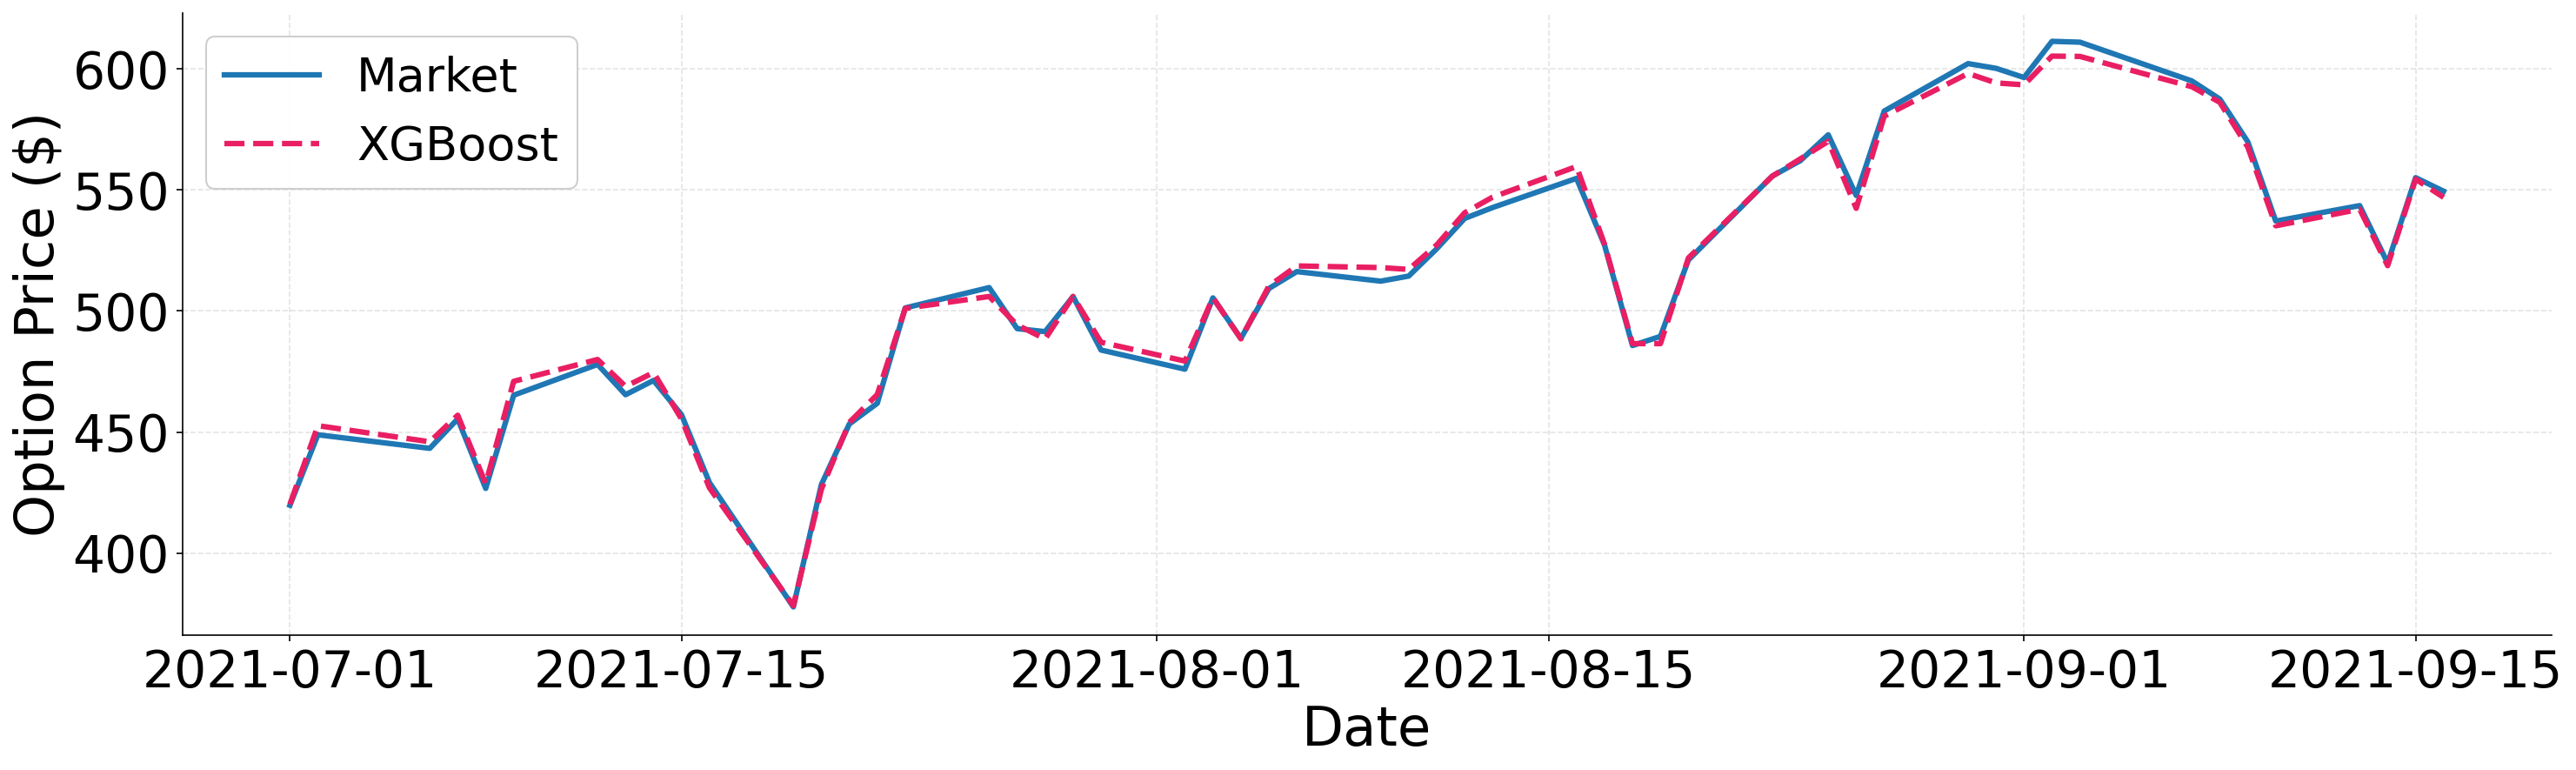

Saved PNG to: C:\Users\samib\OneDrive - Imperial College London\Imperial\Education\Year 4\Masters Project\Code\MastersProject\Results\moneyness\ITM option\market_vs_xgboost_itm.png


In [15]:
# import matplotlib.pyplot as plt
# import matplotlib.dates as mdates

# print(pred_test)

# fig, ax = plt.subplots(figsize=(12,6))

# ax.plot(test_df["date"], test_df["mid"], 
#         label="Market Mid", linewidth=2)

# ax.plot(test_df["date"], pred_test, 
#         label="RF Prediction", linewidth=2, linestyle="--")

# ax.set_title("Option Price: Market vs Random Forest Prediction", fontsize=14)
# ax.set_xlabel("Date")
# ax.set_ylabel("Option Price")

# ax.legend()
# ax.grid(True, alpha=0.3)

# # Better date formatting
# ax.xaxis.set_major_locator(mdates.AutoDateLocator())
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
# plt.xticks(rotation=45)

# plt.tight_layout()
# plt.show()



# ------------------------------------------------------------------
# Market vs ML model plot (ATM, short-dated test option)
# Copy this cell into each ML notebook; change the FOUR lines below.
# ------------------------------------------------------------------
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ---- change these four for each model ----
MODEL_NAME_PRETTY = "XGBoost"
MODEL_COLOUR      = "#E91E63"      # magenta
PRED              = pred_test   # whatever the test predictions are called
FILE_TAG          = "xgboost"

# Reference palette for the other four notebooks:
#   XGBoost  -> "#E91E63"  magenta     tag: "xgboost"
#frandomf forest-> "#8B4513"  brown       tag: "lightgbm"
#   FFNN     -> "#B8860B"  goldenrod   tag: "ffnn"
#   LSTM     -> "#000000"  black       tag: "lstm"

save_dir = Path(r"C:\Users\samib\OneDrive - Imperial College London\Imperial\Education\Year 4\Masters Project\Code\MastersProject\Results\moneyness\ITM option")
save_dir.mkdir(parents=True, exist_ok=True)

# Align predictions with test_df order (safe if test_df was not re-sorted)
plot_df = test_df.copy()
plot_df["date"] = pd.to_datetime(plot_df["date"])
plot_df["pred"] = pd.Series(PRED).values
plot_df = plot_df.sort_values("date").reset_index(drop=True)

# Figure: wider aspect (20:6) so five fit on one A4 page at 0.95\textwidth
fig, ax = plt.subplots(figsize=(20, 6), dpi=150)

ax.plot(plot_df["date"], plot_df["mid"],
        linewidth=3, label="Market")
ax.plot(plot_df["date"], plot_df["pred"],
        linewidth=3, linestyle="--",
        color=MODEL_COLOUR, label=MODEL_NAME_PRETTY)

ax.set_xlabel("Date", fontsize=30)
ax.set_ylabel("Option Price ($)", fontsize=30)
ax.grid(True, which="major", linestyle="--", alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=28)

leg = ax.legend(frameon=True, fontsize=26, loc="best")
leg.get_frame().set_alpha(0.95)

plt.tight_layout()

png_path = save_dir / f"market_vs_{FILE_TAG}_itm.png"
fig.savefig(png_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved PNG to: {png_path}")